### train larger unet

In [ ]:
import matplotlib.pyplot as plt
plt.style.use('dark_background')
import numpy as np
from transformers import CLIPTextModel, CLIPTokenizer
from diffusers.models import AutoencoderKLFlux2
from diffusers import FlowMatchEulerDiscreteScheduler
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

device = "cuda"

In [2]:
text_encoder = CLIPTextModel.from_pretrained("../../stable-diffusion-xl-base-1.0/text_encoder").to("cuda", torch.float32)
tokenizer = CLIPTokenizer.from_pretrained("../../stable-diffusion-xl-base-1.0/tokenizer")
vae = AutoencoderKLFlux2.from_pretrained("../../FLUX.2-klein-4B/vae", device=device).to(device)
scheduler = FlowMatchEulerDiscreteScheduler.from_pretrained("../../FLUX.2-klein-4B/scheduler", device=device)

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

In [3]:
def encode_text_batch_enc1(text_batch):
    inputs = tokenizer(
        text_batch,
        padding="max_length",
        truncation=True,
        max_length=tokenizer.model_max_length,
        return_tensors="pt"
    ).to("cuda")
    
    with torch.no_grad():
        embed = text_encoder(inputs.input_ids, output_hidden_states=True, return_dict=True)
        text_embeds = embed.pooler_output

    return text_embeds


latents_bn_mean = vae.bn.running_mean.view(1, -1, 1, 1).to(device)
latents_bn_std = torch.sqrt(vae.bn.running_var.view(1, -1, 1, 1) + vae.config.batch_norm_eps).to(device)

def patchify_latents(latents):
    batch_size, num_channels_latents, height, width = latents.shape
    latents = latents.view(
        batch_size, num_channels_latents, height // 2, 2, width // 2, 2
    )
    latents = latents.permute(0, 1, 3, 5, 2, 4)
    latents = latents.reshape(
        batch_size, num_channels_latents * 4, height // 2, width // 2
    )
    return latents

def unpatchify_latents(latents):
    batch_size, num_channels_latents, height, width = latents.shape
    latents = latents.reshape(
        batch_size, num_channels_latents // (2 * 2), 2, 2, height, width
    )
    latents = latents.permute(0, 1, 4, 2, 5, 3)
    latents = latents.reshape(
        batch_size, num_channels_latents // (2 * 2), height * 2, width * 2
    )
    return latents

In [4]:
train_batch_size = 128

In [5]:
class LatentsAndEmbedsDataset(Dataset):
    def __init__(self):
        self.embeds = torch.load("../../precomputes/embeds_enc1.pt")
        latents = torch.load("../../precomputes/latents_256x256.pt")
        self.latents = latents
        
    def __len__(self):
        assert len(self.latents) == len(self.embeds)
        return len(self.latents)

    def __getitem__(self, idx):
        return self.latents[idx], self.embeds[idx]

In [6]:
dataset = LatentsAndEmbedsDataset()

In [7]:
print(dataset.latents.shape, dataset.latents.dtype, dataset.latents.device)
print(dataset.embeds.shape, dataset.embeds.dtype, dataset.embeds.device)

torch.Size([591753, 32, 32, 32]) torch.float16 cpu
torch.Size([591753, 768]) torch.float16 cpu


In [8]:
train_loader = DataLoader(dataset, batch_size=train_batch_size, shuffle=True)

torch.Size([128, 32, 32, 32]) cpu torch.float16 tensor(-12.1406, dtype=torch.float16) tensor(11.4688, dtype=torch.float16)
torch.Size([128, 768]) cpu torch.float16 tensor(-7.3555, dtype=torch.float16) tensor(10.6016, dtype=torch.float16)


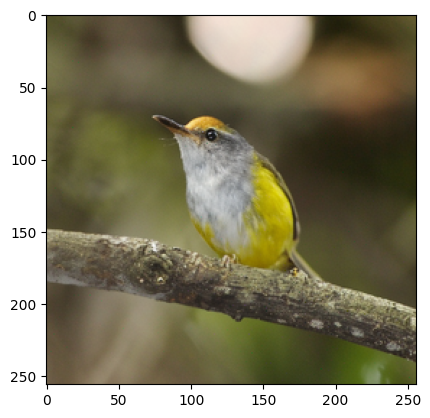

In [9]:
latents, embeds = next(iter(train_loader))
print(latents.shape, latents.device, latents.dtype, latents.min(), latents.max())
print(embeds.shape, embeds.device, embeds.dtype, embeds.min(), embeds.max())

with torch.no_grad():
    # latents = patchify_latents(latents)
    # latents = latents * latents_bn_std.cpu()
    # latents = latents + latents_bn_mean.cpu()
    # latents = unpatchify_latents(latents)
    reconstructed = (vae.decode(latents[:1].cuda().float()).sample + 1.0 ) / 2.0

reconstructed = reconstructed.squeeze(0).permute((1, 2, 0)).cpu().numpy()
reconstructed = np.clip(reconstructed, 0, 1)

plt.imshow(reconstructed)
plt.show()

In [10]:
def make_group_norm(channels: int, max_groups: int = 32, eps: float = 1e-6) -> nn.GroupNorm:
    groups = min(max_groups, channels)
    while channels % groups != 0 and groups > 1:
        groups -= 1
    return nn.GroupNorm(groups, channels, eps=eps)


class AttentionBlock(nn.Module):
    def __init__(
        self, 
        channels: int, 
        num_heads: int = 8, 
        head_dim: int = 64
    ):
        super().__init__()
        self.channels = channels
        self.num_heads = num_heads
        self.head_dim = head_dim
        self.attn_dim = num_heads * head_dim
        
        self.norm = make_group_norm(channels)

        self.to_q = nn.Conv2d(channels, self.attn_dim, kernel_size=1, stride=1, padding=0)
        self.to_k = nn.Conv2d(channels, self.attn_dim, kernel_size=1, stride=1, padding=0)
        self.to_v = nn.Conv2d(channels, self.attn_dim, kernel_size=1, stride=1, padding=0)

        self.to_out = nn.Conv2d(self.attn_dim, channels, kernel_size=1, stride=1, padding=0)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        residual = x
        
        b, c, H, W = x.shape 
        
        h = self.norm(x) 
        
        q = self.to_q(h)
        k = self.to_k(h)
        v = self.to_v(h)

        q = q.view(b, self.num_heads, self.head_dim, H * W).permute(0, 1, 3, 2)
        k = k.view(b, self.num_heads, self.head_dim, H * W).permute(0, 1, 3, 2)
        v = v.view(b, self.num_heads, self.head_dim, H * W).permute(0, 1, 3, 2)
        
        attn_out = F.scaled_dot_product_attention(q, k, v)
 
        attn_out = attn_out.permute(0, 1, 3, 2).reshape(b, self.attn_dim, H, W)

        out = self.to_out(attn_out)
        
        return out + residual


class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim: int = 128, max_period: int = 10000):
        super().__init__()
        self.dim = dim
        self.max_period = max_period

    def forward(self, timesteps: torch.Tensor) -> torch.Tensor:
        half = self.dim // 2
        timesteps = timesteps.float()

        freqs = torch.exp(
            -torch.log(torch.tensor(float(self.max_period), device=timesteps.device))
            * torch.arange(half, device=timesteps.device, dtype=timesteps.dtype)
            / half
        )
        args = timesteps[:, None] * freqs[None]
        emb = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)

        if self.dim % 2 == 1:
            emb = F.pad(emb, (0, 1))

        return emb


class ConditioningEncoder(nn.Module):
    """
    Fuses timestep and text into a single conditioning vector.
    """
    def __init__(self, time_dim: int = 128, text_dim: int = 768, cond_dim: int = 256):
        super().__init__()
        self.time_embed = SinusoidalTimeEmbedding(time_dim)

        self.time_proj = nn.Sequential(
            nn.Linear(time_dim, cond_dim),
            nn.SiLU(),
            nn.Linear(cond_dim, cond_dim),
        )

        self.text_proj = nn.Sequential(
            nn.Linear(text_dim, cond_dim),
            nn.SiLU(),
            nn.Linear(cond_dim, cond_dim),
        )

    def forward(self, timestep: torch.Tensor, text_embed: torch.Tensor) -> torch.Tensor:
        time_vec = self.time_proj(self.time_embed(timestep))
        text_vec = self.text_proj(text_embed)
        return time_vec + text_vec


class ConditionedResidualBlock(nn.Module):
    """
    SDXL-style residual block:
      GN -> SiLU -> Conv
      + condition (scale/shift)
      GN -> SiLU -> Dropout -> Conv
      + skip connection
    """
    def __init__(
        self,
        input_channels: int,
        output_channels: int,
        cond_dim: int = 256,
        dropout: float = 0.0,
    ):
        super().__init__()

        self.norm1 = make_group_norm(input_channels)
        self.conv1 = nn.Conv2d(input_channels, output_channels, kernel_size=3, padding=1)

        self.cond_proj = nn.Sequential(
            nn.SiLU(),
            nn.Linear(cond_dim, 2 * output_channels),
        )

        self.norm2 = make_group_norm(output_channels)
        self.dropout = nn.Dropout(dropout)
        self.conv2 = nn.Conv2d(output_channels, output_channels, kernel_size=3, padding=1)

        if input_channels != output_channels:
            self.skip = nn.Conv2d(input_channels, output_channels, kernel_size=1, bias=False)
        else:
            self.skip = nn.Identity()

    def forward(self, x: torch.Tensor, cond: torch.Tensor) -> torch.Tensor:
        residual = self.skip(x)

        h = self.norm1(x)
        h = F.silu(h)
        h = self.conv1(h)

        scale_shift = self.cond_proj(cond)
        scale, shift = scale_shift.chunk(2, dim=1)

        h = self.norm2(h)
        h = h * (1 + scale[:, :, None, None]) + shift[:, :, None, None]
        h = F.silu(h)
        h = self.dropout(h)
        h = self.conv2(h)

        return h + residual


class ResAttnStage(nn.Module):
    def __init__(
        self,
        input_channels: int,
        output_channels: int,
        cond_dim: int = 256,
        dropout: float = 0.0,
        use_attention: bool = False,
        num_heads: int = 4,
    ):
        super().__init__()
        self.res = ConditionedResidualBlock(
            input_channels=input_channels,
            output_channels=output_channels,
            cond_dim=cond_dim,
            dropout=dropout,
        )
        self.attn = AttentionBlock(output_channels, num_heads=num_heads) if use_attention else nn.Identity()

    def forward(self, x: torch.Tensor, cond: torch.Tensor) -> torch.Tensor:
        x = self.res(x, cond)
        x = self.attn(x)
        return x


class DownStage(nn.Module):
    def __init__(
        self,
        input_channels: int,
        output_channels: int,
        cond_dim: int = 256,
        dropout: float = 0.0,
        num_blocks: int = 1,
        use_attention: bool = False,
        num_heads: int = 4,
    ):
        super().__init__()

        attn_flags = [use_attention] * num_blocks

        self.blocks = nn.ModuleList()
        for i in range(num_blocks):
            in_ch = input_channels if i == 0 else output_channels
            self.blocks.append(
                ResAttnStage(
                    input_channels=in_ch,
                    output_channels=output_channels,
                    cond_dim=cond_dim,
                    dropout=dropout,
                    use_attention=attn_flags[i],
                    num_heads=num_heads,
                )
            )

        self.downsample = nn.AvgPool2d(2)

    def forward(self, x: torch.Tensor, cond: torch.Tensor):
        for block in self.blocks:
            x = block(x, cond)
        skip = x
        x = self.downsample(x)
        return x, skip


class UpStage(nn.Module):
    def __init__(
        self,
        input_channels: int,
        skip_channels: int,
        output_channels: int,
        cond_dim: int = 256,
        dropout: float = 0.0,
        num_blocks: int = 1,
        use_attention: bool = False,
        num_heads: int = 4,
    ):
        super().__init__()

        attn_flags = [use_attention] * num_blocks

        self.upsample = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)

        self.blocks = nn.ModuleList()
        for i in range(num_blocks):
            in_ch = (input_channels + skip_channels) if i == 0 else output_channels
            self.blocks.append(
                ResAttnStage(
                    input_channels=in_ch,
                    output_channels=output_channels,
                    cond_dim=cond_dim,
                    dropout=dropout,
                    use_attention=attn_flags[i],
                    num_heads=num_heads,
                )
            )

    def forward(self, x: torch.Tensor, skip: torch.Tensor, cond: torch.Tensor) -> torch.Tensor:
        x = self.upsample(x)

        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)

        x = torch.cat([x, skip], dim=1)

        for block in self.blocks:
            x = block(x, cond)

        return x


class UNet(nn.Module):
    def __init__(
        self,
        sample_channels: int = 32,
        base_channels: int = 256,
        text_dim: int = 768,
        time_dim: int = 512,
        cond_dim: int = 1024,
        dropout: float = 0.01,
        num_heads: int = 16,
    ):
        super().__init__()

        self.conditioning = ConditioningEncoder(
            time_dim=time_dim,
            text_dim=text_dim,
            cond_dim=cond_dim,
        )

        self.in_conv = nn.Conv2d(sample_channels, base_channels, kernel_size=1, padding=0)

        self.down_stages = nn.ModuleList([
            DownStage(
                input_channels=base_channels,
                output_channels=base_channels,
                cond_dim=cond_dim,
                dropout=dropout,
                num_blocks=2,
                use_attention=False,
                num_heads=num_heads,
            ),
            DownStage(
                input_channels=base_channels,
                output_channels=base_channels * 2,
                cond_dim=cond_dim,
                dropout=dropout,
                num_blocks=4,
                use_attention=True,
                num_heads=num_heads,
            ),
        ])

        self.mid_stages = nn.ModuleList([
            ResAttnStage(
                input_channels=base_channels * 2,
                output_channels=base_channels * 2,
                cond_dim=cond_dim,
                dropout=dropout,
                use_attention=True,
                num_heads=num_heads,
            )
            for _ in range(8)
        ])

        self.up_stages = nn.ModuleList([
            UpStage(
                input_channels=base_channels * 2,
                skip_channels=base_channels * 2,
                output_channels=base_channels,
                cond_dim=cond_dim,
                dropout=dropout,
                num_blocks=4,
                use_attention=True,
                num_heads=num_heads,
            ),
            UpStage(
                input_channels=base_channels,
                skip_channels=base_channels,
                output_channels=base_channels,
                cond_dim=cond_dim,
                dropout=dropout,
                num_blocks=2,
                use_attention=False,
                num_heads=num_heads,
            ),
        ])

        self.out_conv = nn.Conv2d(base_channels, sample_channels, kernel_size=1, padding=0)

    def forward(self, sample: torch.Tensor, timestep: torch.Tensor, text_embed: torch.Tensor) -> torch.Tensor:
        cond = self.conditioning(timestep, text_embed)

        x = self.in_conv(sample)

        skips = []
        for down in self.down_stages:
            x, skip = down(x, cond)
            skips.append(skip)

        for mid in self.mid_stages:
            x = mid(x, cond)

        for up in self.up_stages:
            x = up(x, skips.pop(), cond)

        x = self.out_conv(x)
        return x

In [14]:
unet = UNet()
unet = unet.to(device)

optimizer = torch.optim.AdamW(unet.parameters(), lr=1e-4)
num_train_timesteps = 1000

In [15]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import torch
from IPython.display import clear_output


def _get_next_sample_index(save_directory):
    """
    Finds the next available integer index for sample files
    of the form sample_<index>.png or sample_epochX_<index>.png.
    """
    pattern = re.compile(r"sample_(?:epoch\d+_)?(\d+)\.png")
    max_index = -1

    for fname in os.listdir(save_directory):
        match = pattern.match(fname)
        if match:
            max_index = max(max_index, int(match.group(1)))

    return max_index + 1


def generate_test_sample(save_directory="../../samples/flow/large/l-1", epoch_number=None, prompt = "There are two black dogs on the field of green grass.", cfg = 5.0, save=True):
    os.makedirs(save_directory, exist_ok=True)

    sample_index = _get_next_sample_index(save_directory)

    if epoch_number is not None:
        filename = f"sample_epoch{epoch_number}_{sample_index}.png"
    else:
        filename = f"sample_{sample_index}.png"

    save_path = os.path.join(save_directory, filename)

    text_embed = encode_text_batch_enc1([prompt])
    negative_text_embed = torch.zeros_like(text_embed)
    

    scheduler.set_timesteps(50, mu=1.0)
    latents = torch.normal(0, 1, (1, 32, 32, 32), dtype=torch.float32, device="cuda")
    unet.eval()

    with torch.no_grad():
        for t in scheduler.timesteps:
            latent_model_input = latents
            t = t.to(device).view(1)
            predicted_noise = unet(sample=latent_model_input, timestep=t, text_embed=text_embed)
            negative_predicted_noise = unet(sample=latent_model_input, timestep=t, text_embed=negative_text_embed)

            predicted_noise_cfg = negative_predicted_noise + (predicted_noise - negative_predicted_noise) * cfg
            
            latents = scheduler.step(predicted_noise_cfg, t, latents).prev_sample

    with torch.no_grad():
        latents = patchify_latents(latents)
        latents = latents * latents_bn_std
        latents = latents + latents_bn_mean
        latents = unpatchify_latents(latents)
        image = (vae.decode(latents).sample + 1.0) / 2.0

    image = image.squeeze(0).permute((1, 2, 0)).float().cpu().numpy()
    image = np.clip(image, 0, 1)

    clear_output(wait=True)
    if save:
        plt.imsave(save_path, image)
    plt.imshow(image)
    plt.axis("off")
    plt.show()

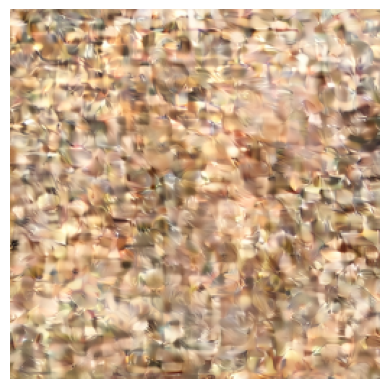

In [16]:
generate_test_sample()

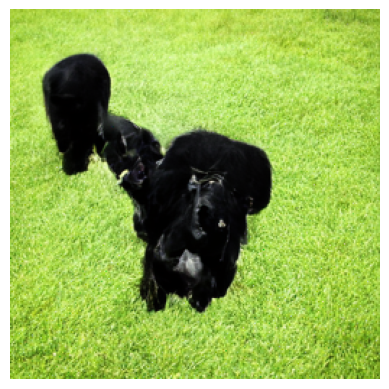

 75%|███████▌  | 3484/4624 [17:59<05:53,  3.23it/s]


KeyboardInterrupt: 

In [191]:
from torch.utils.tensorboard import SummaryWriter

writer = SummaryWriter(log_dir="../../runs/flow/large/l-1")

epochs = 1000

for epoch in range(27, epochs):
    num_steps = 0
    loss_sum = 0
    unet.train()
    for latents, text_embeds in tqdm(train_loader):
        num_steps += 1
        batch_size = latents.shape[0]
        latents = latents.cuda().float()

        latents = patchify_latents(latents)
        latents -= latents_bn_mean
        latents /= latents_bn_std
        latents = unpatchify_latents(latents)

        text_embeds = text_embeds.cuda().float()
        embed_mask = torch.randint(0, 100, (batch_size, 1), device=device) > 5
        embed_mask = embed_mask.float()
        embed_mask = embed_mask.repeat(1, text_embeds.shape[1])
        text_embeds = text_embeds * embed_mask

        timesteps = torch.randint(0, num_train_timesteps, (batch_size,), device=device)
        noise = torch.randn_like(latents)
        sigmas = timesteps / num_train_timesteps
        sigmas = sigmas[:,None,None,None]
        noisy_latents = latents * (1 - sigmas) + noise * sigmas

        predicted_velocity = unet(sample=noisy_latents, timestep=timesteps, text_embed=text_embeds)

        target = noise - latents

        loss = ((target - predicted_velocity)**2).mean()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        loss_sum += float(loss.item())

        if num_steps % 100 == 0:
            generate_test_sample(epoch_number=epoch)
            unet.train()

    writer.add_scalar("train_loss", loss_sum / num_steps, epoch)
    generate_test_sample(epoch_number=epoch)

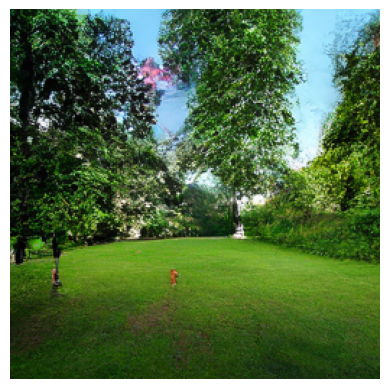

In [194]:
generate_test_sample(prompt="There is a man walking on the path in the park.", cfg=5)

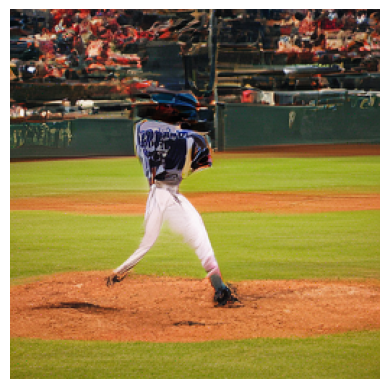

In [195]:
generate_test_sample(prompt="Baseball player on the field", cfg=5)

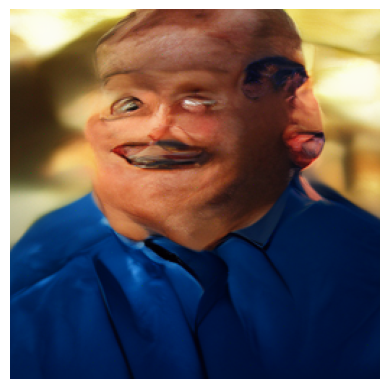

In [197]:
generate_test_sample(prompt="A man's face", cfg=5)

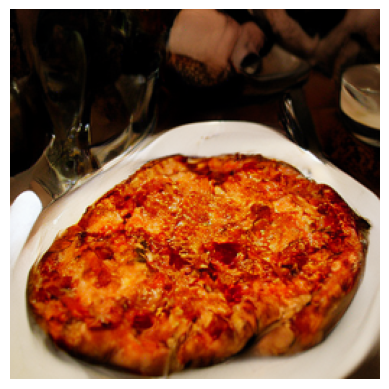

In [199]:
generate_test_sample(prompt="A plate with pizza on the table.", cfg=5)

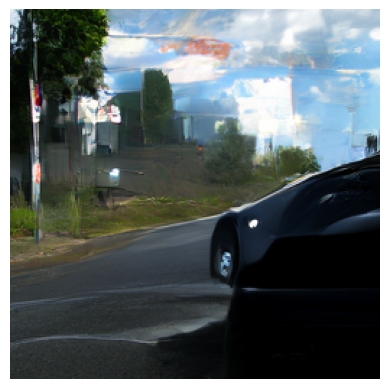

In [268]:
generate_test_sample(prompt="A black car on the road", cfg=5)

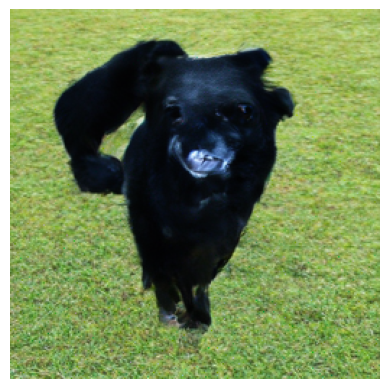

In [252]:
generate_test_sample(prompt="There is a black dog standing on the field.", cfg=5)

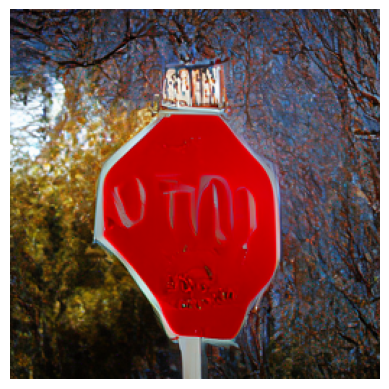

In [271]:
generate_test_sample(prompt="A red stop sign with text 'STOP'", cfg=5)

In [192]:
torch.save(unet.state_dict(), '../../trained_models/flow_unet_l-1.1.pth')

In [269]:
state_dict = torch.load('../../trained_models/flow_unet_l-1.1.pth', weights_only=True)

unet.load_state_dict(state_dict)

<All keys matched successfully>

In [270]:
total_params = sum(p.numel() for p in unet.parameters())
print("Total parameters:", total_params)

Total parameters: 117467936
